# 📊 **APE_007_Normal**

# 🧠 **Integrantes:**

*   Noelia Bustan
*   Alison Tapia
*   Cristofer Pineda
*   Elian Jimenez
*   Yimmy Angulo
-----------------

## 📝 **Introducción**

En este trabajo grupal se implementaron manualmente funciones estadísticas utilizando Python y Jupyter Notebook para analizar un dataset real de casos de dengue.

Se realizaron cálculos de media y varianza tanto de forma manual como con NumPy, con el objetivo de comprender cómo funcionan internamente estas operaciones estadísticas y comparar los resultados obtenidos.


## **📥 Importación de Librerías**

In [ ]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

## **💾 Carga del Dataset**

In [ ]:

df = pd.read_excel('Datos_Dengue_MSP_Ene2021_Ago2025(2).xlsx')

print("Dimensiones del dataset:")
print(df.shape)

df.head()


---
# **Filtración del Rango a la provincia de Loja**

In [ ]:
# Filtrar únicamente los registros de la provincia de Loja
loja = df[df["Provincia"] == "LOJA"]

# Variable seleccionada para el análisis
variable = loja["Total"]

print("Provincia analizada: Loja")
print("Variable seleccionada: Total (casos totales de dengue)")
print("Número de registros de Loja:")
print(loja.shape)

Provincia analizada: LOJA
Variable seleccionada: Total (casos totales de dengue)
Número de registros de Loja:
(697, 33)


---
# **🛠️ Hito 1: Modelado Gaussiano Teórico y Estandarización (Tareas 1 y 2)**



# TAREA 1

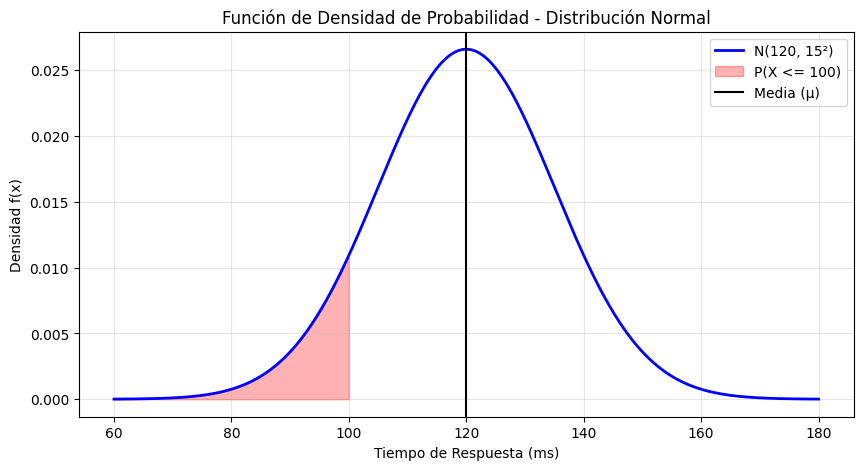

La probabilidad de que el servidor responda en 100ms o menos es: 0.0912 (9.12%)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros poblacionales
mu = 120
sigma = 15

# Definición del dominio (eje X): usualmente de mu-4sigma a mu+4sigma
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# Cálculo de la PDF teórica
pdf_normal = norm.pdf(x, loc=mu, scale=sigma)

# Configuración del gráfico
plt.figure(figsize=(10, 5))
plt.plot(x, pdf_normal, 'b', lw=2, label=f'N({mu}, {sigma}²)')

# Sombreado del área de interés: P(X<=100)
x_fill = np.linspace(mu - 4*sigma, 100)
y_fill = norm.pdf(x_fill, loc=mu, scale=sigma)
plt.fill_between(x_fill, y_fill, color='red', alpha=0.3, label='P(X <= 100)')

# Formato y etiquetas del gráfico
plt.title('Función de Densidad de Probabilidad - Distribución Normal')
plt.xlabel('Tiempo de Respuesta (ms)')
plt.ylabel('Densidad f(x)')
plt.axvline(mu, color='k', linestyle='-', label='Media (μ)')
plt.legend()
plt.grid(True, alpha=0.3)

# Mostrar el gráfico
plt.show()

# Cálculo analítico de la probabilidad usando CDF
prob_100 = norm.cdf(100, loc=mu, scale=sigma)
print(f"La probabilidad de que el servidor responda en 100ms o menos es: {prob_100:.4f} ({prob_100*100:.2f}%)")

---
## TAREA 2
---

In [6]:
import pandas as pd
from scipy.stats import norm

# Leer el archivo Excel
df = pd.read_excel("Datos_Dengue_MSP_Ene2021_Ago2025(2).xlsx")

# Seleccionar la columna Total
total = df["Total"]

# Calcular media y desviación estándar
mu = total.mean()
sigma = total.std()

# Valor dado
X = 145

# Calcular valor Z
Z = (X - mu) / sigma

# Mostrar resultado
print("Media:", mu)
print("Desviación estándar:", sigma)
print("Valor Z:", Z)

# Calcular P(X >= 145)
probabilidad = 1 - norm.cdf(Z, loc=0, scale=1)

print("P(X >= 145):", probabilidad)

Media: 3.849506279895941
Desviación estándar: 6.282989123578123
Valor Z: 22.46550024898336
P(X >= 145): 0.0


---
# **🛠️ Hito 2: Hito del Proyecto - Aplicación Probabilística Regional (ABP)**
---

             DESARROLLO DE LA TAREA 3 UNL             
Punto 2: Variable Continua Seleccionada -> Edad
Punto 3: Media Muestral (mu)            -> 21.95 años
         Desviación Estándar (sigma)    -> 16.90 años
Punto 4: Rango del Escenario [a, b]     -> [65 a 100 años]
Punto 5: Probabilidad (Decimales)       -> 0.0054
         Probabilidad (Porcentaje)      -> 0.54%


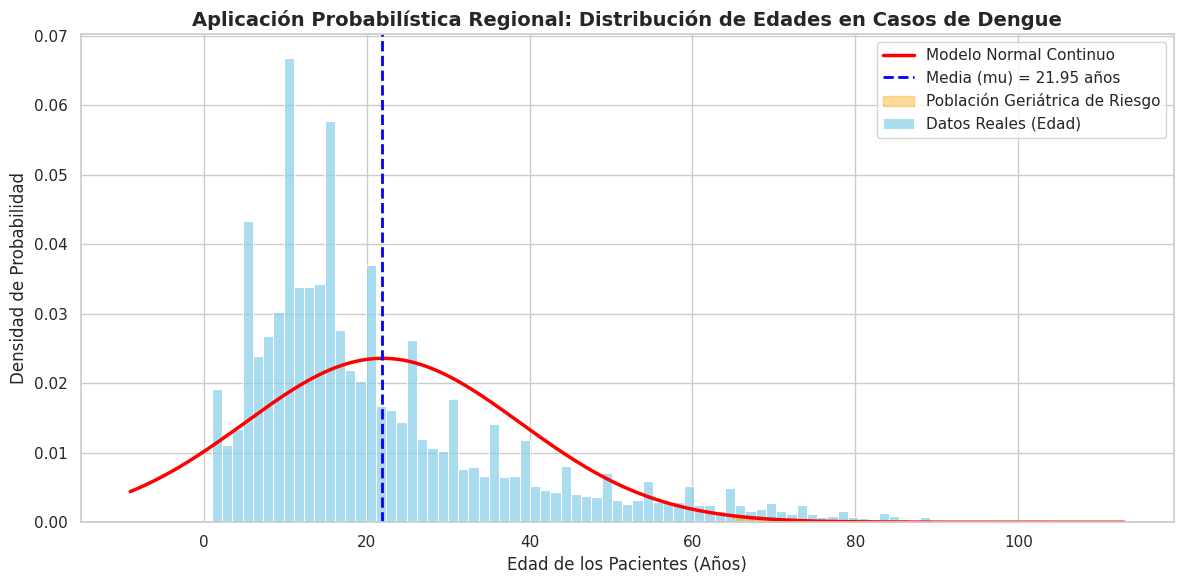

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

# ==============================================================================
# 1. CARGA DEL DATASET DE LA PESTAÑA CORRECTA
# ==============================================================================
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Archivo de Excel en tu Colab
archivo_excel = "Datos_Dengue_MSP_Ene2021_Ago2025(2).xlsx"

df_regional = pd.read_excel(archivo_excel, sheet_name='DCSA_DG_2021_2025')
df_regional.columns = df_regional.columns.str.strip()

# ==============================================================================
# 2. SELECCIÓN DE LA VARIABLE DE NATURALEZA CONTINUA
# ==============================================================================
variable = 'Edad'
df_regional[variable] = pd.to_numeric(df_regional[variable], errors='coerce')
datos = df_regional[variable].dropna()

# ==============================================================================
# 3. EXTRAER PARÁMETROS: MEDIA (mu) Y DESVIACIÓN ESTÁNDAR (sigma)
# ==============================================================================
mu = datos.mean()        # Media muestral (µ)
sigma = datos.std()      # Desviación estándar muestral (σ)

# ==============================================================================
# 4. DEFINIR UN ESCENARIO PROBLEMÁTICO [a, b]
# ==============================================================================
# Escenario: Riesgo de complicaciones en Adultos Mayores (65 a 100 años)
a = 65
b = 100

# ==============================================================================
# 5. CALCULAR PROBABILIDAD UTILIZANDO LA DISTRIBUCIÓN NORMAL
# ==============================================================================
probabilidad_critica = norm.cdf(b, loc=mu, scale=sigma) - norm.cdf(a, loc=mu, scale=sigma)
porcentaje = probabilidad_critica * 100

# ==============================================================================
# IMPRESIÓN DE RESULTADOS ACORDE A LA RÚBRICA
# ==============================================================================
print("="*50)
print("             DESARROLLO DE LA TAREA 3 UNL             ")
print("="*50)
print(f"Punto 2: Variable Continua Seleccionada -> {variable}")
print(f"Punto 3: Media Muestral (mu)            -> {mu:.2f} años")
print(f"         Desviación Estándar (sigma)    -> {sigma:.2f} años")
print(f"Punto 4: Rango del Escenario [a, b]     -> [{a} a {b} años]")
print(f"Punto 5: Probabilidad (Decimales)       -> {probabilidad_critica:.4f}")
print(f"         Probabilidad (Porcentaje)      -> {porcentaje:.2f}%")
print("="*50)

# ==============================================================================
# GRÁFICO OBLIGATORIO: HISTOGRAMA + CURVA NORMAL
# ==============================================================================
plt.figure(figsize=(12, 6))

# Histograma real de densidades de las Edades
sns.histplot(datos, kde=False, stat="density", color="skyblue", alpha=0.7, label="Datos Reales (Edad)")

# Curva teórica Normal Gaussiana
x = np.linspace(datos.min() - 10, datos.max() + 10, 500)
plt.plot(x, norm.pdf(x, mu, sigma), color="red", linewidth=2.5, label="Modelo Normal Continuo")

# Línea de la Media
plt.axvline(mu, color="blue", linestyle="--", linewidth=2, label=f"Media (mu) = {mu:.2f} años")

# Sombreado del área bajo la curva para el rango [65, 100]
x_critico = np.linspace(a, b, 200)
plt.fill_between(x_critico, norm.pdf(x_critico, mu, sigma), color="orange", alpha=0.4, label="Población Geriátrica de Riesgo")

plt.title('Aplicación Probabilística Regional: Distribución de Edades en Casos de Dengue', fontsize=14, fontweight='bold')
plt.xlabel('Edad de los Pacientes (Años)')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.tight_layout()
plt.show()

# **Hito 3: Análisis del Error Estándar y la Ley de los Grandes Números (Tarea 4: ABI)**

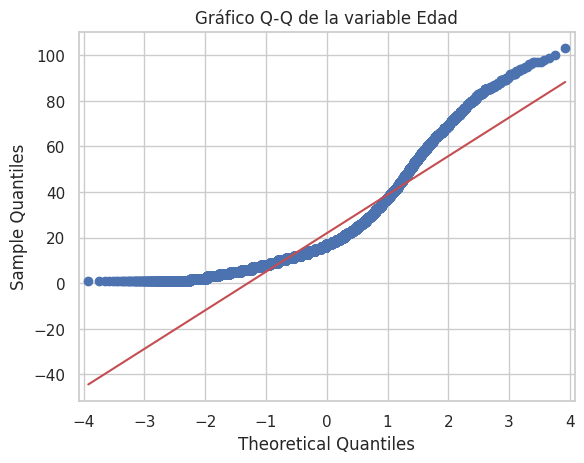

VALIDACIÓN DE NORMALIDAD - SHAPIRO WILK
Estadístico de Shapiro-Wilk: 0.8569
p-valor: 1.994130e-55

Conclusión: Se rechaza H0.
La variable Edad NO sigue una distribución normal.
Hipótesis nula (H₀): La variable Edad sigue una distribución normal.
Hipótesis alternativa (H₁): La variable Edad no sigue una distribución normal.
Regla de decisión:
 
* Si p > 0.05, no se rechaza H₀.
* Si p ≤ 0.05, se rechaza H₀.
La conclusión definitiva dependerá del valor p obtenido en el test de Shapiro-Wilk y de la observación del gráfico Q-Q.


In [4]:
## TAREA 4: ABI - VALIDACIÓN MATEMÁTICA DEL SUPUESTO DE NORMALIDAD

### 1. Método Gráfico: Gráfico Q-Q

import statsmodels.api as sm
import matplotlib.pyplot as plt

# Utilizar la misma variable analizada en la Tarea 3
datos_variable = datos

sm.qqplot(datos_variable, line='s')
plt.title('Gráfico Q-Q de la variable Edad')
plt.show()


### 2. Método Analítico: Test de Shapiro-Wilk


from scipy.stats import shapiro

# Se toma una muestra aleatoria debido al tamaño del dataset
muestra = datos_variable.sample(
    min(5000, len(datos_variable)),
    random_state=42
)

stat, p_value = shapiro(muestra)

print("="*60)
print("VALIDACIÓN DE NORMALIDAD - SHAPIRO WILK")
print("="*60)
print(f"Estadístico de Shapiro-Wilk: {stat:.4f}")
print(f"p-valor: {p_value:.6e}")

if p_value > 0.05:
    print("\nConclusión: No se rechaza H0.")
    print("La variable Edad puede considerarse aproximadamente normal.")
else:
    print("\nConclusión: Se rechaza H0.")
    print("La variable Edad NO sigue una distribución normal.")

### Interpretación
print("Hipótesis nula (H₀): La variable Edad sigue una distribución normal.")
print("Hipótesis alternativa (H₁): La variable Edad no sigue una distribución normal.")

print("Regla de decisión:")
print(" ");

print("* Si p > 0.05, no se rechaza H₀.")
print("* Si p ≤ 0.05, se rechaza H₀.")

### Conclusión

print("La conclusión definitiva dependerá del valor p obtenido en el test de Shapiro-Wilk y de la observación del gráfico Q-Q.")


---
# **🛠️ Hito 4: Preguntas de Control**
---

###**✔ Pregunta 1: Matemáticamente, ¿por qué en una variable aleatoria continua modelada por una función de densidad f(x) la probabilidad de que tome un valor exacto es cero, es decir, P(X = c) = 0?.**


En una variable aleatoria continua, la probabilidad de obtener un valor exacto es cero porque las probabilidades se calculan como el área bajo la función de densidad en un intervalo. Matemáticamente:

$$
P(X=c)=\int_{c}^{c} f(x)\,dx = 0
$$

Esto ocurre porque los límites de integración son iguales, por lo que el intervalo tiene longitud cero y, en consecuencia, el área bajo la curva también es cero. Esto no significa que el valor \(c\) sea imposible de observar, sino que la probabilidad de obtener exactamente un único valor en una distribución continua es nula. Por esta razón, las probabilidades en variables continuas se calculan sobre intervalos de valores, por ejemplo:

$$
P(a \leq X \leq b)=\int_{a}^{b} f(x)\,dx
$$

donde el resultado corresponde al área bajo la curva de densidad entre los valores \(a\) y \(b\).

### **✔ Pregunta 2: Interprete conceptualmente qué significa que un valor de su dataset regional tenga un puntaje estándar Z = -2.45. ¿Se consideraría un valor atípico bajo el criterio de la regla empírica?.**


En el dataset regional de casos de dengue, un puntaje estándar de **Z = -2.45** indica que la edad correspondiente se encuentra **2.45 desviaciones estándar por debajo de la edad promedio** de los pacientes registrados. Esto significa que se trata de una edad considerablemente menor que la media observada en la variable **Edad**.

Matemáticamente, el puntaje Z se interpreta como:

$$
Z=\frac{X-\mu}{\sigma}
$$

donde $ (X)$ es la edad observada, $\mu $ es la media de las edades y $\sigma$ es la desviación estándar.

De acuerdo con la regla empírica, aproximadamente el 95% de los datos de una distribución normal se encuentra dentro del intervalo:

$$
\mu \pm 2\sigma
$$

y el 99.7% dentro de:

$$
\mu \pm 3\sigma
$$

Como el valor $ Z=-2.45 $ se encuentra fuera del intervalo de $ \pm 2\sigma\ $, la observación puede considerarse poco frecuente dentro del conjunto de datos. Sin embargo, dado que:

$$
|Z| = 2.45 < 3
$$

no se clasifica como un valor atípico extremo bajo el criterio de la regla empírica. Por lo tanto, corresponde a una edad inusualmente baja respecto al promedio de los pacientes con dengue, pero aún podría formar parte de la variabilidad normal presente en el dataset.

### **✔ Pregunta 3: ¿Qué riesgo metodológico existe al tomar decisiones basadas en el cálculo normal si la gráfica de la variable real presenta un fuerte sesgo (skewness)?.**

Existe el riesgo metodológico de que las probabilidades calculadas mediante la distribución normal no representen adecuadamente el comportamiento real de los datos. La distribución normal asume simetría alrededor de la media, por lo que cuando los datos están sesgados, las estimaciones de probabilidades, percentiles e intervalos pueden resultar inexactas.



### **✔ Pregunta 4: Si el p-valor del test de Shapiro-Wilk es 0.001, ¿cuál es la conclusión estadística respecto a la distribución de sus datos regionales?. ¿Se invalida con esto el cálculo realizado en la Tarea 3?.**


Si el p-valor obtenido en el test de Shapiro-Wilk es **0.001**, entonces se cumple que:

$$
p = 0.001 < 0.05
$$

Por lo tanto, se rechaza la hipótesis nula de normalidad y se concluye que la variable **Edad** del dataset regional de casos de dengue no sigue una distribución normal.

Sin embargo, esto no invalida completamente el cálculo realizado en la Tarea 3. El procedimiento matemático utilizado para estimar la probabilidad de que la edad de los pacientes se encuentre entre 65 y 100 años mediante una distribución normal sigue siendo correcto desde el punto de vista teórico. No obstante, dado que los datos reales no cumplen el supuesto de normalidad, la probabilidad obtenida debe interpretarse como una aproximación y no como una representación exacta del comportamiento de la población analizada.

En consecuencia, el resultado calculado en la Tarea 3 puede utilizarse con fines descriptivos y académicos, pero debe señalarse que la variable **Edad** presenta desviaciones respecto a la distribución normal. Esto implica que las probabilidades estimadas podrían diferir de las probabilidades reales observadas en el dataset, especialmente en las colas de la distribución.

### **✔ Pregunta 5: Explique el principio matemático detrás del gráfico Q-Q. ¿Qué representan los cuantiles teóricos en el eje X versus los cuantiles empíricos en el eje Y?.**

En el eje **X** se representan los **cuantiles teóricos**, es decir, los valores que se esperarían obtener si la variable **Edad** siguiera exactamente una distribución normal con los parámetros estimados ($\mu$ y $\sigma$). En el eje **Y** se representan los **cuantiles empíricos**, que corresponden a los valores observados en el dataset regional de casos de dengue una vez ordenados de menor a mayor.

Si los datos siguen aproximadamente una distribución normal, los puntos del gráfico se alinearán cerca de una línea recta diagonal. Por el contrario, si los puntos se desvían sistemáticamente de dicha línea, esto indica diferencias entre la distribución observada y la distribución normal teórica.

Matemáticamente, la comparación se realiza entre:
$Q_{\text{teórico}}(p)$ y $ Q_{\text{empírico}}(p)$.

donde \(p\) representa un percentil o nivel de probabilidad determinado.

